# Day 1

In [ ]:
import os
from transformers import logging
import torch
from datasets import load_dataset
from google.colab import drive
drive.mount('/content/drive')
os.environ['HF_HOME']=os.path.join('.','new')
os.environ['CUDA_VISIBLE_DEVICES']='0'
logging.set_verbosity_error()
device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu' )
if device.type=='cuda':
  print(torch.cuda.get_device_name(0))
base_path = "/content/drive/MyDrive/dataset"
dataset=load_dataset('csv',
                     data_files={
                         "train": os.path.join(base_path,"data_train.csv"),
                          "test": os.path.join(base_path,"data_eval.csv")
                     })
with open(os.path.join(base_path,'answer_space.txt')) as f:
  answer_space=f.read().splitlines()
dataset = dataset.map(
    lambda examples: {
        'label': [
            answer_space.index(ans.replace(" ", "").split(",")[0])
            for ans in examples['answer']
        ]
    },
    batched=True
)






Mounted at /content/drive
NVIDIA A100-SXM4-80GB


Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/9974 [00:00<?, ? examples/s]

Map:   0%|          | 0/2494 [00:00<?, ? examples/s]

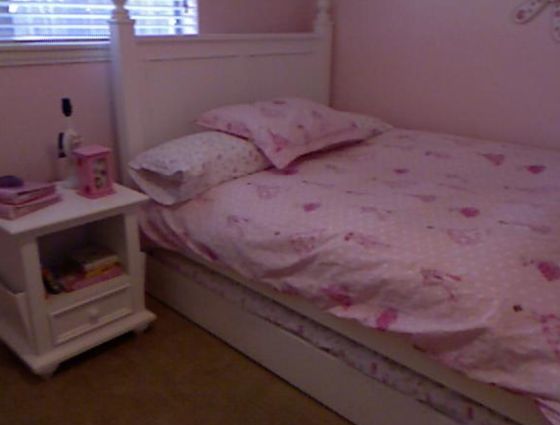

QUESTION: 	 what is the bed sheet colour
ANSWER: 	 pink (Label:	387)


In [ ]:

import numpy as np
from  IPython.display import display
from PIL import Image
def Image_path(image_id):
  for ext in ['.png','.jpeg','.jpg']:
    path=os.path.join(base_path,"images",image_id+ext)
    if os.path.exists(path):
      return path
  raise FileNotFoundError(f'image {image_id} is not present')

def show_image(train=True,id=None):
  data=dataset["train"] if train else dataset["test"]
  if id is None:
    id=np.random.randint(len(data))

  imagepath=Image_path(data[id]['image_id'])
  image=Image.open(imagepath)
  display(image)
  print("QUESTION: \t",data[id]['question'])
  print('ANSWER: \t',data[id]['answer'],f"(Label:\t{data[id]['label']})")
show_image()



In [ ]:

from transformers import AutoImageProcessor,AutoTokenizer
from typing import List
class Multlimodalcollator:
  tokenizer: AutoTokenizer
  prprocessor: AutoImageProcessor
  def get_image_path(self,image_id):
    for ext in['.png','jpg','jpeg']:
      path=os.path.join(base_path,"images",image_id+ext)
      if path.os.exists(path):
        return path
    raise FileNotFoundError(f"image {image_id} is not present")
  def tokenizer_text(self,texts:List[str]):
    encoded_text=self.tokenizer(
        text=texts,
        padding='longest',
        max_lenght=24,
        truncate=True,
        return_tenson='pt',
        return_token_type_id=True,
        return_attention_mask=True,
    )
    return{
        "input_id":encoded_text['input_id'],
        "token_type_id": encoded_text['token_type_id'],
        "attentio_mask":encoded_text['attention_mask']
    }
    def preprocess_image(self,images: List[str]):
      processed_image= self.prprocessor(
          images=[
              Image.open(self.get_image_path(image_id)).convert('RGB')
              for image_id in images
          ], return_tensors='pt',
      )
      return {
          "pixel_values": processed_image['pixel_values',]
      }
    def __call__(self, raw_batch_dict):
        return {
            **self.tokenize_text(
                raw_batch_dict['question']
                if isinstance(raw_batch_dict, dict) else
                [i['question'] for i in raw_batch_dict]
            ),
            **self.preprocess_images(
                raw_batch_dict['image_id']
                if isinstance(raw_batch_dict, dict) else
                [i['image_id'] for i in raw_batch_dict]
            ),
            'labels': torch.tensor(
                raw_batch_dict['label']
                if isinstance(raw_batch_dict, dict) else
                [i['label'] for i in raw_batch_dict],
                dtype=torch.int64
            ),
        }

# Learn below

class MultimodalVQAModel(nn.Module):
    def __init__(
            self,
            num_labels: int = len(answer_space),
            intermediate_dim: int = 512,
            pretrained_text_name: str = 'bert-base-uncased',
            pretrained_image_name: str = 'google/vit-base-patch16-224-in21k'):

        super().__init__()

        self.text_encoder = AutoModel.from_pretrained(pretrained_text_name)
        self.image_encoder = AutoModel.from_pretrained(pretrained_image_name)

        self.fusion = nn.Sequential(
            nn.Linear(
                self.text_encoder.config.hidden_size +
                self.image_encoder.config.hidden_size,
                intermediate_dim
            ),
            nn.ReLU(),
            nn.Dropout(0.5),
        )

        self.classifier = nn.Linear(intermediate_dim, num_labels)
        self.criterion = nn.CrossEntropyLoss()

    def forward(
            self,
            input_ids,
            pixel_values,
            attention_mask=None,
            token_type_ids=None,
            labels=None):

        # Text encoder
        text_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            return_dict=True,
        )

        # Image encoder
        image_out = self.image_encoder(
            pixel_values=pixel_values,
            return_dict=True,
        )

        # ✅ FIXED: use correct outputs
        text_feat = text_out.pooler_output
        image_feat = image_out.last_hidden_state[:, 0]

        fused = self.fusion(
            torch.cat([text_feat, image_feat], dim=1)
        )

        logits = self.classifier(fused)

        output = {"logits": logits}

        if labels is not None:
            loss = self.criterion(logits, labels)
            output["loss"] = loss

        return output
def createMultimodalVQACollatorAndModel(text='bert-base-uncased', image='google/vit-base-patch16-224-in21k'):
    tokenizer = AutoTokenizer.from_pretrained(text)
    from transformers import AutoImageProcessor
    preprocessor = AutoImageProcessor.from_pretrained(image)

    multi_collator = MultimodalCollator(
        tokenizer=tokenizer,
        preprocessor=preprocessor,
    )


    multi_model = MultimodalVQAModel(pretrained_text_name=text, pretrained_image_name=image).to(device)
    return multi_collator, multi_model
import nltk
nltk.download('wordnet')
def wup_measure(a,b,similarity_threshold=0.925):
    """
    Returns Wu-Palmer similarity score.
    More specifically, it computes:
        max_{x \in interp(a)} max_{y \in interp(b)} wup(x,y)
        where interp is a 'interpretation field'
    """
    def get_semantic_field(a):
        weight = 1.0
        semantic_field = wordnet.synsets(a,pos=wordnet.NOUN)
        return (semantic_field,weight)


    def get_stem_word(a):
        """
        Sometimes answer has form word\d+:wordid.
        If so we return word and downweight
        """
        weight = 1.0
        return (a,weight)


    global_weight=1.0

    (a,global_weight_a)=get_stem_word(a)
    (b,global_weight_b)=get_stem_word(b)
    global_weight = min(global_weight_a,global_weight_b)

    if a==b:
        # they are the same
        return 1.0*global_weight

    if a==[] or b==[]:
        return 0


    interp_a,weight_a = get_semantic_field(a)
    interp_b,weight_b = get_semantic_field(b)

    if interp_a == [] or interp_b == []:
        return 0

    # we take the most optimistic interpretation
    global_max=0.0
    for x in interp_a:
        for y in interp_b:
            local_score = x.wup_similarity(y) or 0
            if local_score > global_max:
                global_max=local_score

    # we need to use the semantic fields and therefore we downweight
    # unless the score is high which indicates both are synonyms
    if global_max < similarity_threshold:
        interp_weight = 0.1
    else:
        interp_weight = 1.0

    final_score=global_max*weight_a*weight_b*interp_weight*global_weight
    return final_score